In [1]:
import sys
sys.path.append('/users/odarwish/lenscarf/lib/python3.12/site-packages')

import numpy as np

import matplotlib.pyplot as plt

import numpy as np

import yaml

from pathlib import Path


import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from matplotlib.ticker import LogLocator, LogFormatter, AutoMinorLocator
from matplotlib.gridspec import GridSpec
from matplotlib import patheffects
import matplotlib as mpl

# ---- CONFIGURATION ----
# Use golden ratio for figure dimensions
GOLDEN_RATIO = (5**0.5 - 1) / 2
FIG_WIDTH = 5  # inches
FIG_HEIGHT = FIG_WIDTH * GOLDEN_RATIO
DPI = 300

# Check for and configure LaTeX if available (optional but professional)
# Uncomment this if you have LaTeX installed
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],
# })

# If not using LaTeX, use a clean serif font
# Try to use TeX fonts that are included with matplotlib
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "Times New Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm"  # Use Computer Modern math font
})

# Define a modern, colorblind-friendly palette with higher contrast
# Based on colorblindness-friendly scientific palettes like viridis
# and ones recommended by Nature and Science publications
COLORBLIND_PALETTE = [
    '#0072B2',  # Blue
    '#D55E00',  # Orange
    '#009E73',  # Green
    '#CC79A7',  # Pink
    '#56B4E9',  # Light blue
    '#E69F00',  # Yellow
    '#000000',  # Black
    '#F0E442'   # Light yellow
]

In [2]:
key_selected = "n"

# More descriptive and professionally formatted names
names = {
    "n": r"$\mathcal{D}$",          # Using calligraphic D for density
    "x": r"$\varepsilon$",           # Using proper epsilon symbol
    "s": r"$\mathcal{S}$",           # Calligraphic S
    "t": r"$\mathcal{T}$",           # Calligraphic T
    "g": r"$\mathcal{G}$",           # Calligraphic G
    "x2": r"$10\varepsilon$"         # 10 epsilon
}

estimators_all = ["s", "g", "t", "n", "x", "x2"]
estimators_base = ["s", "g", "t", "x"]

In [3]:
configuration = '../configs/abacus/config_abacus_thy.yaml'
configuration = '../configs/abacus/config_abacus_recs.yaml'


with open(configuration, 'r') as f:
    config = yaml.safe_load(f)

ps_main_directory = config['power_spectrum']['main_directory']
name_config = config['name']
gen_nl_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['nonlinear'])
gen_power = np.loadtxt(ps_main_directory+name_config+"/"+config['power_spectrum']['linear'])

output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

#ic = load_dens(ic_dir, sim_name, ngrid)
import jax.numpy as jnp
pnlinf = lambda kmag: jnp.interp(kmag, gen_nl_power[:,0], gen_nl_power[:,1])
plinf = lambda kmag: jnp.interp(kmag, gen_power[:,0], gen_power[:,1])

kmin, kmax = config['k_range']['kmin'], config['k_range']['kmax']

output_config = config['output']
filename_prefix = output_config['filename_prefix']
filename_prefix = output_config['filename_prefix']
output_dir = Path(output_config['directory'])/config['name']

nome = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_normalization_AB.npy"
nomev = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_variance_AB.npy"
#nometri = "analysisAbacusSummit_base_c000_ph000_z0.500_LRG_ELG_shot_trispectrum_AB.npy"
#out_normalization_AB = np.load(output_dir / f"{filename_prefix}_normalization_AB.npy", allow_pickle = True).item()

out_normalization_AB = np.load(output_dir / nome, allow_pickle = True).item()
#out_variance_AB = np.load(output_dir / f"{filename_prefix}_variance_AB.npy", allow_pickle = True).item()
#analysis_cross_shot_AB = np.load(output_dir / f"{filename_prefix}_cross_shot_AB.npy", allow_pickle = True).item()
out_variance_AB_other = np.load(output_dir / nomev, allow_pickle = True).item()
#out_shot_trispectrum = np.load(output_dir / nometri, allow_pickle = True).item()

kr_config = config['k_range']
kmin = kr_config['kmin']
kmax = kr_config['kmax']
k_samples = kr_config['k_samples']
k_min_analysis = kr_config['k_min_analysis']
k_max_analysis = kr_config['k_max_analysis']

kmin_max = 2*k_min_analysis
Ks_ = np.linspace(k_min_analysis, kmin_max, 20)
Ks = np.logspace(np.log10(kmin_max), np.log10(k_max_analysis), k_samples)
Ks = np.concatenate([Ks_, Ks])
Ks = np.unique(Ks)


Ks = np.linspace(k_min_analysis, k_max_analysis, k_samples)

In [4]:
direc = f"/users/odarwish/colabdata/results/{config['name']}/"
Ns = 3

In [5]:
import jax
from jax import numpy as jnp
def symm(f, A, B, **kwargs):
    return (f(A, B, **kwargs)+f(B, A, **kwargs))/2
def asymm(f, A, B, **kwargs):
    return (f(A, B, **kwargs)-f(B, A, **kwargs))/2

def bs2_coev(b10):
  """
  Coevolution value of the bs2 parameter
  """
  return -2./7.*(b10-1)

def b2_fit(b10):
    return 2*(0.412-2.143*b10 + 0.929*b10**2 + 0.008*b10**3)

def br_formula(b1, z = 0.5):
    h = 0.6736
    H0 = h*100
    bias = 6.8*((1+z)*H0)**-1.*(b1-1) #formula 20 from Schmidt 2016
    return bias

def bGX(b10):
    factor = 1421/510
    return br_formula(b10)*factor

def bSX(b10):
    factor = 17/6
    return br_formula(b10)*factor

def bTX(b10):
    factor = 91/30
    return br_formula(b10)*factor

In [6]:
def cg_g(biases_A, biases_B, e):
    return (biases_A[0]+21/17*biases_A[1]+e*biases_A[2])*biases_B[0]

def cg_s(biases_A, biases_B, e):
    return (biases_A[0]+e*biases_A[1])*biases_B[0]

def cg_t(biases_A, biases_B, e):
    return (biases_A[0]+7/2*biases_A[1]+e*biases_A[2])*biases_B[0]

b1A = 1.6
b1B = 2
e = 1e-3

b2A, b2B = b2_fit(b1A), b2_fit(b1B)
bGXA, bGXB = bGX(b1A), bGX(b1B)
bSXA, bSXB = bSX(b1A), bSX(b1B)
bs2A, bs2B = bs2_coev(b1A), bs2_coev(b1B)
bTXA, bTXB = bTX(b1A), bTX(b1B)

def get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB, zero_shift = 1.):
    """
    Cg = jnp.array([Cg_g, Cg_ga, Cg_s, Cg_sa, Cg_t, Cg_ta])
    """

    biases_A_G = jnp.array([b1A, b2A, bGXA])
    biases_B_G = jnp.array([b1B, b2B, bGXB])

    biases_A_S = jnp.array([b1A, bSXA])
    biases_B_S = jnp.array([b1B, bSXB])

    biases_A_T = jnp.array([b1A, bs2A, bTXA])
    biases_B_T = jnp.array([b1B, bs2B, bTXB])

    Cg_g = symm(cg_g, biases_A_G, biases_B_G, e = e) #need to change definition of symm and asymm
    Cg_ga = asymm(cg_g, biases_A_G, biases_B_G, e = e)

    Cg_s = symm(cg_s, biases_A_S, biases_B_S, e = e)
    Cg_sa = asymm(cg_s, biases_A_S, biases_B_S, e = e)*zero_shift

    Cg_t = symm(cg_t, biases_A_T, biases_B_T, e = e)
    Cg_ta = asymm(cg_t, biases_A_T, biases_B_T, e = e)

    Cg = jnp.array([Cg_g, Cg_ga, Cg_s, Cg_sa, Cg_t, Cg_ta])

    return Cg
    
get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB)
#get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB, zero_shift = 0.)

Array([ 1.5178119e+00, -1.3109118e+00,  3.2002671e+00, -3.8146973e-05,
        1.8002857e+00,  1.9995916e-01], dtype=float32)

In [7]:
symm(cg_s, [2, 3], [3, 4], e = e), symm(cg_s, [2, 3], [3, 4], e = 10)

(6.0085, 91.0)

In [8]:
grad_Cg_all = jax.grad(get_Cg_biases, argnums=list(range(12)))

In [9]:
# For Fisher matrix calculations, you probably want the Jacobian
def get_Cg_jacobian():
    """Get Jacobian of Cg w.r.t. all parameters except zero_shift"""
    
    def Cg_func(params):
        e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB = params
        return get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB, zero_shift=1)
    
    return jax.jacfwd(Cg_func)

# Usage
jacobian_func = get_Cg_jacobian()
params = jnp.array([e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB])
J = jacobian_func(params)  # Shape: (6, 13)

In [10]:
keys = ["g", "ga", "s", "sa", "t", "ta"]
labels = [r"$\mathrm{\mathcal{G}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{S}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{T}}_{\mathrm{symm}}$", r"$\mathrm{\mathcal{G}}_{\mathrm{asymm}}$", r"$\mathrm{\mathcal{S}}_{\mathrm{asymm}}$", r"$\mathrm{\mathcal{T}}_{\mathrm{asymm}}$"]
key = "n"

num_keys = 6  # For g, s, t, ga, sa, ta

N = np.array(out_normalization_AB[(key, key)]**-1.)
N[N>1e10] = 0
N = jnp.array(N)

jax_out_normalization_AB = np.empty((len(keys), len(Ks)))
for i, k in enumerate(keys):
    jax_out_normalization_AB[i, :] = out_normalization_AB[(key, k)]
jax_out_normalization_AB = jnp.array(jax_out_normalization_AB)

In [11]:
from interpax import Interpolator1D
plinf_jax = Interpolator1D(gen_power[:,0], gen_power[:,1], method="cubic")

In [12]:
def get_bias_jax(v, zero_shift = 1):
    e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    cg_values = get_Cg_biases(e, b1A, b1B, b2A, b2B, bGXA, bGXB, bSXA, bSXB, bs2A, bs2B, bTXA, bTXB, zero_shift)
    partials = N * jax_out_normalization_AB * cg_values[:, jnp.newaxis]
    # Sum across keys to get the total bias
    bias = jnp.sum(partials, axis=0)
    return jnp.nan_to_num(bias)


def get_bias_jax_A_eq_B(v, zero_shift = 1):
    """
    Here, I assume A and B biases are the same, except for the higher order ones!
    """

    e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB = v
    b1B, b2B, bs2B = b1A, b2A, bs2A

    w = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
   
    return get_bias_jax(w, zero_shift)


def E_bottaro():
    z_eq = 3400
    a_eq = 1/(1+z_eq)
    a = 1.
    fchi = 1.
    factor = jnp.log(a/a_eq)-181/90
    factor *= fchi
    factor *= 6/5
    return factor

def G(epsilon, one = 1):
    E = E_bottaro()
    return 1+epsilon*E*one

def get_total_cross(v, Ks, one = 0, zero_shift = 1):
    #v has e, b1A, b2A, bs2A, bGXA, bSXA, bTXA, bGXB, bSXB, bTXB
    b1C = v[1]*G(v[0], one)**3
    return b1C*get_bias_jax_A_eq_B(v, zero_shift)*plinf(Ks)


variance = jnp.array(out_variance_AB_other[(key, key)])*N**2

def get_total_auto(v, Ks, rec_noise = 0, one = 0, zero_shift = 1):
    #v has e, b1A, b2A, bs2A, bGXA, bSXA, bTXA, bGXB, bSXB, bTXB
    return G(v[0], one)**4*get_bias_jax_A_eq_B(v, zero_shift)**2*plinf(Ks)+variance*rec_noise


def get_galaxy_auto(v, Ks, one = 0):
    #v has e, b1A, b2A, bs2A, bGXA, bSXA, bTXA, bGXB, bSXB, bTXB
    return v[1]**2*plinf(Ks)*G(v[0], one)**2


In [13]:
bGXA, bGXB, bSXA, bSXB, bTXA, bTXB

(0.11250989707046716,
 0.18751649511744525,
 0.11441013460015839,
 0.19068355766693063,
 0.12248614410134602,
 0.20414357350224335)

In [14]:
e = 1e-3
v = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])
v_no_x = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA*0, bGXB*0, bSXA*0, bSXB*0, bTXA*0, bTXB*0])
v_only_sx = jnp.array([e, b1A, b1B, b2A, b2B, bs2A, bs2B, bGXA*0, bGXB*0, bSXA, bSXB, bTXA*0, bTXB*0])

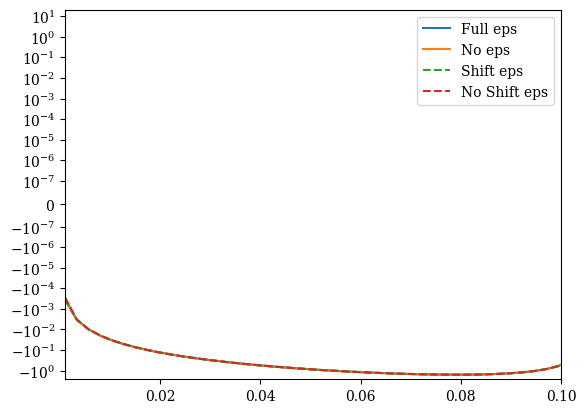

In [15]:
plt.plot(Ks, get_bias_jax(v), label = "Full eps")
plt.plot(Ks, get_bias_jax(v_no_x), label = "No eps")
plt.plot(Ks, get_bias_jax(v_only_sx), label = "Shift eps", ls = "--")
plt.plot(Ks, get_bias_jax(v_only_sx, 0), label = "No Shift eps", ls = "--")

plt.xlim(1e-3, 1e-1)
plt.yscale("symlog", linthresh = 1e-7) 
plt.legend()

In [16]:
sys.path.append('/users/odarwish/qeep')

from qeep import fisher

In [17]:
def s123(k1, k2):
    """
    Fix third leg to be smaller than the other two.
    """
    if k1 == k2:
        return 2
    else:
        return 1

def bispectrum_derivative(k1, k2, k3):
    return 1

def power_spectrum_A(k):
    return 1

def power_spectrum_B(k):
    return 1

def F2D_bispectrum_integrand(k1, k2, k3):
    result = bispectrum_derivative(k1, k2, k3)**2
    variance = s123(k1, k2)*power_spectrum_A(k1)*power_spectrum_A(k2)
    result /= variance
    result *= k1*k2
    return result

In [18]:
K_array = Ks
vA = jnp.array([e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB])

In [19]:
def get_cov(rec_noise = 0, one = 0, zero_eps_shift = 1, shot = 0):
    @jax.jit
    def covariance_full(K_array, v):
        """
        This covariance includes:
        galaxy power spectrum A
        reconstruction cross spectrum A-R
        reconstruction auto spectrum R
    
        We assume b1 biases are same for A and B, hence we just include 2 probes

        If rec_noise = 0, no rec noise in auto-reconstruction. rec_noise = 1, includes it.
        If one = 0, not growth term. one = 1, include growth term.
        If zero_eps_shift = 1, you include shift asymmetric terms. zero_eps_shift = 0, you null them.
        """
        
        n_probes = 2
        
        #P = plinf_jax(K_array)
    
        CAR = get_total_cross(v, Ks, one, zero_shift = zero_eps_shift) #gets cross-spectrum
        CRR = get_total_auto(v, Ks, rec_noise, one, zero_shift = zero_eps_shift) #gets reconstruction auto-spectrum
        CAA = get_galaxy_auto(v, Ks, one)+shot #gets galaxy auto-spectrum
    
        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        #R, A
        C = C.at[:, 0, 0].set(CRR)
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 1, 1].set(CAA)
        
        return C
    return covariance_full





def get_cov_ignoring(rec_noise = 0, one = 0, zero_eps_shift = 1, shot = 0, CRR = get_total_auto(vA, Ks, 0, 0, zero_shift = 1), CAA = get_galaxy_auto(vA, Ks, 0)):
    @jax.jit
    def covariance_full(K_array, v):
        """
        This covariance includes:
        galaxy power spectrum A
        reconstruction cross spectrum A-R
        reconstruction auto spectrum R
    
        We assume b1 biases are same for A and B, hence we just include 2 probes

        If rec_noise = 0, no rec noise in auto-reconstruction. rec_noise = 1, includes it.
        If one = 0, not growth term. one = 1, include growth term.
        If zero_eps_shift = 1, you include shift asymmetric terms. zero_eps_shift = 0, you null them.
        """
        
        n_probes = 2
        
        #P = plinf_jax(K_array)
    
        CAR = get_total_cross(v, Ks, one, zero_shift = zero_eps_shift) #gets cross-spectrum
        #CRR = get_total_auto(v, Ks, rec_noise, one, zero_shift = zero_eps_shift) #gets reconstruction auto-spectrum
        #CAA = get_galaxy_auto(v, Ks, one)+shot #gets galaxy auto-spectrum
    
        C = jnp.zeros((len(K_array), n_probes, n_probes))
        
        #R, A
        C = C.at[:, 0, 0].set(CRR)
        C = C.at[:, 0, 1].set(CAR)
        C = C.at[:, 1, 0].set(CAR)
        C = C.at[:, 1, 1].set(CAA)
        
        return C
    return covariance_full

In [20]:
Ofunc = lambda K_arr, v: get_total_cross(v, K_arr)
Ofunc_no_shift = lambda K_arr, v: get_total_cross(v, K_arr, zero_shift = 0)

variance_func = lambda K_arr, v: (get_galaxy_auto(v, K_arr))*(get_total_auto(v, K_arr)+jnp.array(out_variance_AB_other[(key, key)])*N**2)
F_single = fisher.fisher_per_mode_single(vA, K_array, Ofunc, variance_func) #Ofunc(K_array, v) returns (n_modes, nprobes, nprobes)
F_single = jnp.nan_to_num(F_single)

variance_func_no_rec_noise = lambda K_arr, v: (get_galaxy_auto(v, K_arr))*(get_total_auto(v, K_arr))
F_single_no_var = fisher.fisher_per_mode_single(vA, K_array, Ofunc, variance_func_no_rec_noise) #Ofunc(K_array, v) returns (n_modes, nprobes, nprobes)
F_single_no_var = jnp.nan_to_num(F_single_no_var)


F_single_no_shift = fisher.fisher_per_mode_single(vA, K_array, Ofunc_no_shift, variance_func) #Ofunc(K_array, v) returns (n_modes, nprobes, nprobes)
F_single_no_shift = jnp.nan_to_num(F_single_no_shift)

In [21]:
derivative_cross_bias_no_shift = jax.jacfwd(lambda v: Ofunc_no_shift(Ks, v))(vA)
derivative_cross_bias = jax.jacfwd(lambda v: Ofunc(Ks, v))(vA)

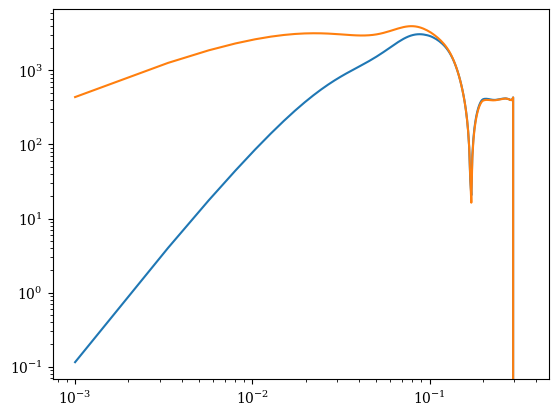

In [22]:
plt.loglog(Ks, abs(derivative_cross_bias_no_shift[:, 0]))
plt.loglog(Ks, abs(derivative_cross_bias[:, 0]))

In [23]:
def get_F_integrated(K_array, F, k_min_analysis = 0.01, k_max_analysis = 0.05, V = 1):
    """
    Given a Fisher matrix per mode, integrates to give a function.
    For now, no mu dependence assumed in F.

    V is in Gpc^3 h^{-3}
    """

    V *= 1e9 #to Mpc^3 h^{-3}

    n_params = F.shape[1]

    Finterp = fisher.get_F_interp(K_array, F)

    K_min = k_min_analysis
    K_max = k_max_analysis

    KK = np.linspace(K_min, K_max, 50)

    F_integrated = jnp.zeros((n_params, n_params))

    Finterpolated = Finterp(KK)

    for a in range(n_params):
        for b in range(a, n_params):
            result = jnp.trapezoid(KK**2*Finterpolated[..., a, b], KK)
            F_integrated = F_integrated.at[a, b].set(result)
            if a != b:
                F_integrated = F_integrated.at[b, a].set(result)

    # Multiply by prefactor (factor of 2 from mu integration)
    F_integrated = F_integrated * (2 * V / (2 * jnp.pi)**2)

    return F_integrated



def get_simple_error_alt(F, fast = True, Kmin = 0.001, Kmax = 0.05):
    
    err_ms, err_us = [], []
    Kmaxarr = min(0.1, Kmax)
    modes = jnp.linspace(Kmin, Kmaxarr, 20)
    for KK in modes:
        err_m, err_u = fisher.get_error_bars_from_F(get_F_integrated(K_array, F, KK, Kmax, V = 1))
        err_ms.append(err_m)
        err_us.append(err_u)

    err_ms = jnp.array(err_ms)
    err_us = jnp.array(err_us)

    return modes, err_ms, err_us


def get_simple_error(F, fast = True, Kmin = 0.001, Kmax = 0.05):
    
    err_ms, err_us = [], []
    
    Kmaxarr = min(0.1, Kmax)
    modes = jnp.linspace(Kmin, Kmaxarr, 20)

    for KK in modes:
        if not fast:
            err_m, err_u = fisher.get_error_bars_from_F(fisher.get_F_integrated(K_array, F, KK, Kmax, V = 1))
        else:
            err_m, err_u = fisher.get_error_bars_from_F(fisher.get_F_integrated_fast(K_array, F, KK, Kmax, V = 1))
        err_ms.append(err_m)
        err_us.append(err_u)

    err_ms = jnp.array(err_ms)
    err_us = jnp.array(err_us)

    return modes, err_ms, err_us

In [24]:
#plt.loglog(Ks, F_single_no_shift[:, 0, 0]**-0.5)
#plt.loglog(Ks, F_single[:, 0, 0]**-0.5)

m, a, b = get_simple_error(F_single_no_shift)
#plt.plot(m, a[:, 0])

m1, aa, bb = get_simple_error_alt(F_single_no_shift)
m2, aa, bb2 = get_simple_error_alt(F_single_no_shift, Kmax = 0.10)

m, a_s, b_s = get_simple_error(F_single)
#plt.plot(m, a_s[:, 0])

m4, aa, bb4 = get_simple_error_alt(F_single, Kmax = 0.15)

m3, aa, bb3 = get_simple_error_alt(F_single_no_shift, Kmax = 0.05)
m5, aa, bb5 = get_simple_error_alt(F_single, Kmax = 0.05)

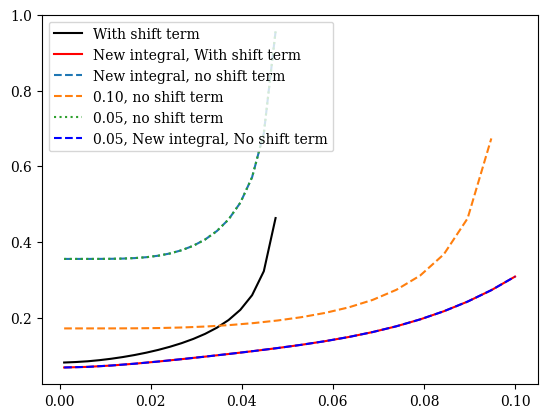

In [25]:
index = 0
#plt.plot(m, b[:, index], label = "No shift term")
plt.plot(m, b_s[:, index], label = "With shift term", color = "black")
plt.plot(m4, bb4[:, index], label = "New integral, With shift term", color = "red")
plt.plot(m1, bb[:, index], label = "New integral, no shift term", ls = "--")
plt.plot(m2, bb2[:, index], ls = "--", label = "0.10, no shift term")

plt.plot(m3, bb3[:, index], ls = ":", label = "0.05, no shift term")
plt.plot(m4, bb4[:, index], label = "0.05, New integral, No shift term", color = "blue", ls = "--")

plt.legend()

In [26]:
def safe_fisher_inversion(F, reg_factor=1e-8):
    """Safely invert Fisher matrix with regularization"""
    F_reg = F + reg_factor * jnp.eye(F.shape[-1])
    try:
        F_inv = jnp.linalg.inv(F_reg)
        # Check if inversion was successful
        if jnp.any(jnp.isnan(F_inv)) or jnp.any(jnp.isinf(F_inv)):
            print("Warning: Matrix inversion produced NaN/Inf")
            return None
        return F_inv
    except:
        print("Matrix inversion failed")
        return None

In [27]:
F = fisher.fisher_per_mode(vA, K_array, get_cov())
F_with_variance = fisher.fisher_per_mode(vA, K_array, get_cov(rec_noise = jnp.array(1)))
F_with_variance_half = fisher.fisher_per_mode(vA, K_array, get_cov(rec_noise = jnp.array(0.5)))
F_with_variance_no_shift = fisher.fisher_per_mode(vA, K_array, get_cov(rec_noise = jnp.array(1), zero_eps_shift = jnp.array(0)))

In [28]:
F_with_variance_growth = fisher.fisher_per_mode(vA, K_array, get_cov(rec_noise = 1, one = 1))

In [29]:
#v = [e, b1A, b2A, bs2A, bGXA, bGXB, bSXA, bSXB, bTXA, bTXB]
#let's marginalize over bias parameters only, e, b1A, b2A, bs2A
F_sub = F[:, :4, :4]

F_with_variance_sub = F_with_variance[:, :4, :4]

F_with_variance_half_sub = F_with_variance_half[:, :4, :4]

F_with_variance_growth_sub = F_with_variance_growth[:, :4, :4]

param_indices = [0, 1, 2, 3, 6, 7]
F_with_variance_sub_big = F_with_variance_sub[:, param_indices][:, :, param_indices]

In [30]:
inv = jnp.linalg.inv(cov)

NameError: name 'cov' is not defined

In [ ]:
jnp.allclose(get_cov_ignoring()(Ks, vA), get_cov()(Ks, vA))

In [ ]:
dC_dv_ign = jax.jacfwd(get_cov_ignoring(), argnums=1)(K_array, vA)
dC_dv = jax.jacfwd(get_cov(), argnums=1)(K_array, vA)

cov_ign = get_cov_ignoring()(K_array, vA)
cov = get_cov()(K_array, vA)
Cinv_ign = fisher.safe_inv(cov_ign)
Cinv = fisher.safe_inv(cov)

Fisher_ign = jnp.einsum('kij,kjla,klm, kmib ->kab', Cinv, dC_dv_ign, Cinv, dC_dv_ign)
Fisher = jnp.einsum('kij,kjla,klm, kmib ->kab', Cinv, dC_dv, Cinv, dC_dv)

In [ ]:
Fisher_ign.shape

In [ ]:
#plt.plot(Ks, dC_dv[:, 1, 0, 0])
#plt.plot(Ks, dC_dv[:, 0, 0, 0])

plt.plot(Ks, dC_dv[:, 1, 1, 0])

plt.plot(Ks, dC_dv_ign[:, 0, 0, 0])

In [ ]:
F_alt_bisp = fisher.fisher_per_mode(vA, K_array, get_cov_ignoring())

F_alt_bisp_sub = F_alt_bisp[:, :4, :4]
modes, check_ms, check_us = get_simple_error(F_alt_bisp_sub)

modes, check_ms_2, check_us_2 = get_simple_error(F_single_no_var[:, :4, :4])

modes, err_single_sub_ms, err_single_sub_us = get_simple_error(F_single[:, :4, :4])

In [ ]:
#plt.loglog(modes, check_us[:, 0])
plt.loglog(modes, check_us_2[:, 0], label = "Single No variance")
plt.loglog(modes, err_single_sub_us[:, 0], ls = "--", label = "Single W variance")
plt.legend()

In [38]:
F_sub_2 = F[:, :6, :6]

In [39]:
F_single_sub = F_single[:, :4, :4]
F_single_sub_2 = F_single[:, :6, :6]
modes, err_single_sub_ms, err_single_sub_us = get_simple_error(F_single_sub)

In [40]:
F_single_no_shift_sub = F_single_no_shift[:, :4, :4]
modes, err_single_no_shift_sub_ms, err_single_no_shift_sub_us = get_simple_error(F_single_no_shift_sub)

In [106]:
import time
s = time.time()
modes, err_sub_ms, err_sub_us = get_simple_error(F_sub)
print(time.time()-s)

"""
s = time.time()
modes, err_sub_ms_, err_sub_us_ = get_simple_error(F_sub, fast = True)
print(time.time()-s)
jnp.allclose(err_sub_us, err_sub_us_)
"""

5.86675763130188


'\ns = time.time()\nmodes, err_sub_ms_, err_sub_us_ = get_simple_error(F_sub, fast = True)\nprint(time.time()-s)\njnp.allclose(err_sub_us, err_sub_us_)\n'

In [107]:
import time
s = time.time()
modes, err_sub_big_ms, err_sub_big_us = get_simple_error(F_with_variance_sub_big, fast = True)
print(time.time()-s)

"""
s = time.time()
modes, err_sub_big_ms_, err_sub_big_us_ = get_simple_error(F_sub_big, fast = True)
print(time.time()-s)
jnp.allclose(jnp.err_sub_big_ms(err_ms_), jnp.nan_to_num(err_sub_big_ms_))
"""

6.915642023086548


'\ns = time.time()\nmodes, err_sub_big_ms_, err_sub_big_us_ = get_simple_error(F_sub_big, fast = True)\nprint(time.time()-s)\njnp.allclose(jnp.err_sub_big_ms(err_ms_), jnp.nan_to_num(err_sub_big_ms_))\n'

In [108]:
modes, err_with_variance_sub_ms, err_with_variance_sub_us = get_simple_error(F_with_variance_sub)

In [109]:
modes, err_with_variance_growth_sub_ms, err_with_variance_growth_sub_us = get_simple_error(F_with_variance_growth_sub)

In [110]:
modes, err_with_variance_ms, err_with_variance_us = get_simple_error(F_with_variance, fast = True)

In [111]:
modes, err_with_variance_half_sub_ms, err_with_variance_half_sub_us = get_simple_error(F_with_variance_half_sub)

In [112]:
modes, err_sub_2_ms, err_sub_2_us = get_simple_error(F_sub_2)

In [113]:
F_F_with_variance_no_shift_sub = F_with_variance_no_shift[:, :4, :4]
modes, err_with_variance_no_shift_sub_ms, err_with_variance_no_shift_sub_us = get_simple_error(F_F_with_variance_no_shift_sub)

In [114]:
import time
s = time.time()
modes, err_ms, err_us = get_simple_error(F)
print(time.time()-s)


"""
s = time.time()
modes, err_ms_, err_us_ = get_simple_error(F, fast = True)
print(time.time()-s)
jnp.allclose(jnp.nan_to_num(err_ms_), jnp.nan_to_num(err_ms))
"""

7.007927656173706


'\ns = time.time()\nmodes, err_ms_, err_us_ = get_simple_error(F, fast = True)\nprint(time.time()-s)\njnp.allclose(jnp.nan_to_num(err_ms_), jnp.nan_to_num(err_ms))\n'

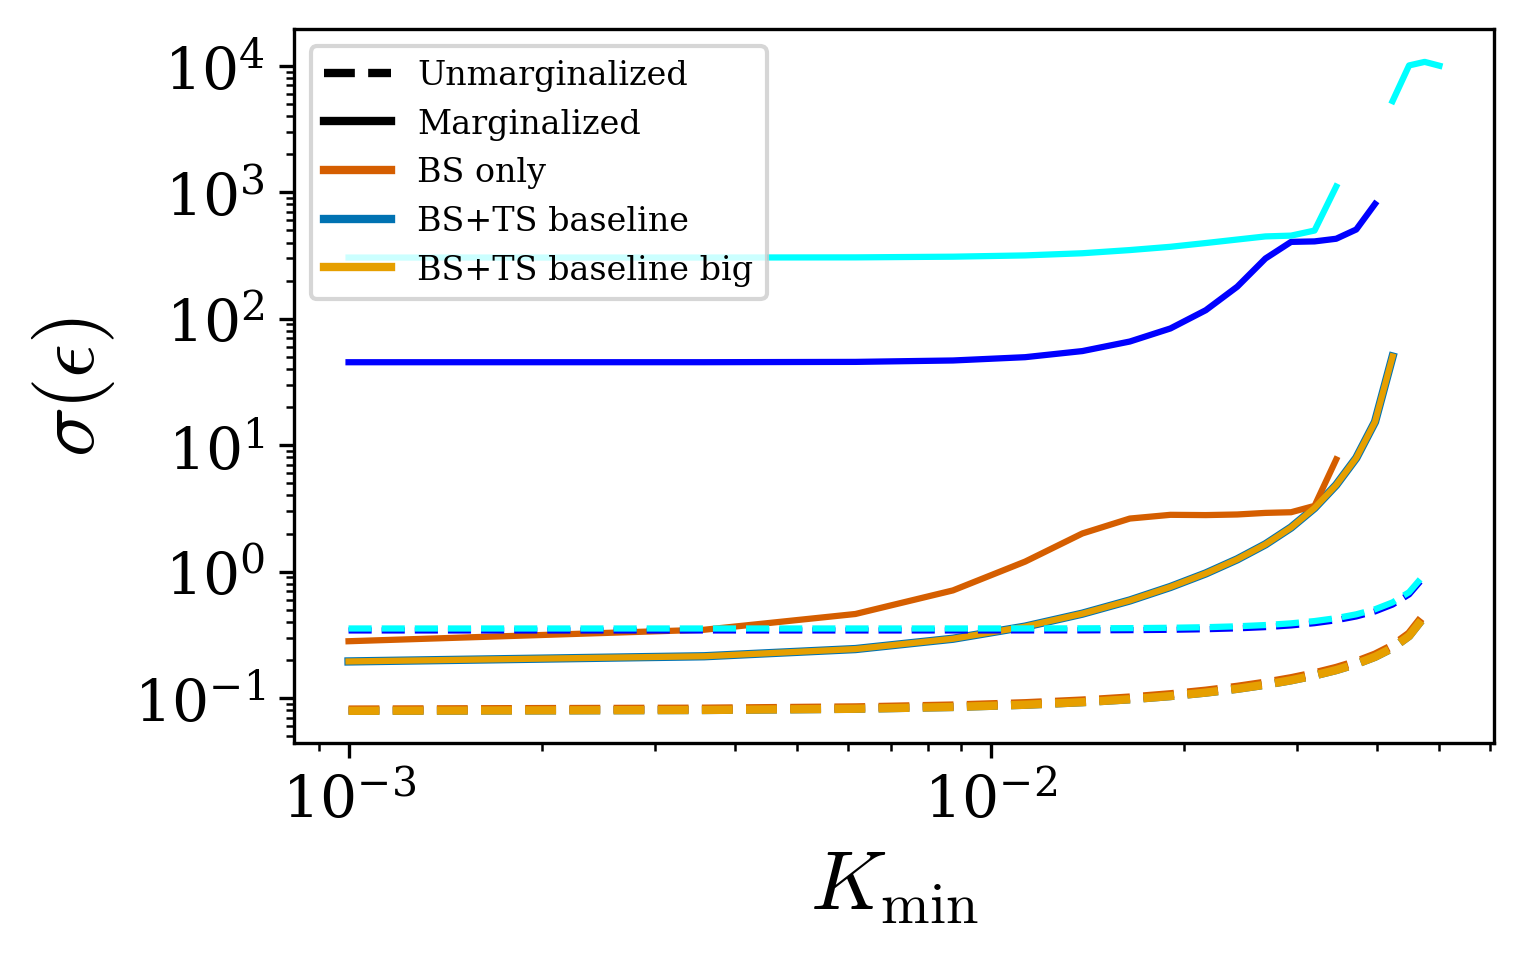

In [115]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])


index = 0

p1 = ax.plot(modes, err_with_variance_sub_us[:, index], ls = "--", color = COLORBLIND_PALETTE[0], lw = 2)
ax.plot(modes, err_with_variance_sub_ms[:, index], color = p1[0].get_color(), lw=2)

#ax.plot(modes, err_sub_2_us[:, 0], ls = "--", color = "green")
#ax.plot(modes, err_sub_2_ms[:, 0], color = "green")

#ax.plot(modes, err_us[:, 0], color = "blue", ls = ":")
#ax.plot(modes, err_ms[:, 0], ls = "--", color = "blue")

p2 = ax.plot(modes, err_single_sub_us[:, index], ls = "--", color = COLORBLIND_PALETTE[1], lw = 2)
ax.plot(modes, err_single_sub_ms[:, index], color = p2[0].get_color())

p6 = ax.plot(modes, err_sub_big_us[:, index], ls = "--", color = COLORBLIND_PALETTE[5], lw = 2)
ax.plot(modes, err_sub_big_ms[:, index], ls = "-", color = p6[0].get_color())

#err_with_variance_no_shift_sub_ms, err_with_variance_no_shift_sub_us
ax.plot(modes, err_with_variance_no_shift_sub_us[:, index], ls = "--", color = "blue")
ax.plot(modes, err_with_variance_no_shift_sub_ms[:, index], ls = "-", color = "blue")

ax.plot(modes, err_single_no_shift_sub_us[:, index], ls = "--", color = "cyan")
ax.plot(modes, err_single_no_shift_sub_ms[:, index], ls = "-", color = "cyan")

ax.set_yscale("log")

ax.set_xlabel(r"$K_{\mathrm{min}}$", fontsize = 20)
ax.set_ylabel(r"$\sigma(\epsilon)$", fontsize = 20)


ax.tick_params(axis='both', which='major', width=0.8, 
               labelsize=14)


legend_elements = [Line2D([0], [0], color='black', lw=2, ls='--', label='Unmarginalized'),
                   Line2D([0], [0], color='black', lw=2, label='Marginalized'),
                   Line2D([0], [0], color=p2[0].get_color(), lw=2, label='BS only'),
                   Line2D([0], [0], color=p1[0].get_color(), lw=2, label='BS+TS baseline'),
                   Line2D([0], [0], color=p6[0].get_color(), lw=2, label='BS+TS baseline big'),
                  ]
ax.legend(handles=legend_elements, fontsize=8)
ax.set_xscale("log")

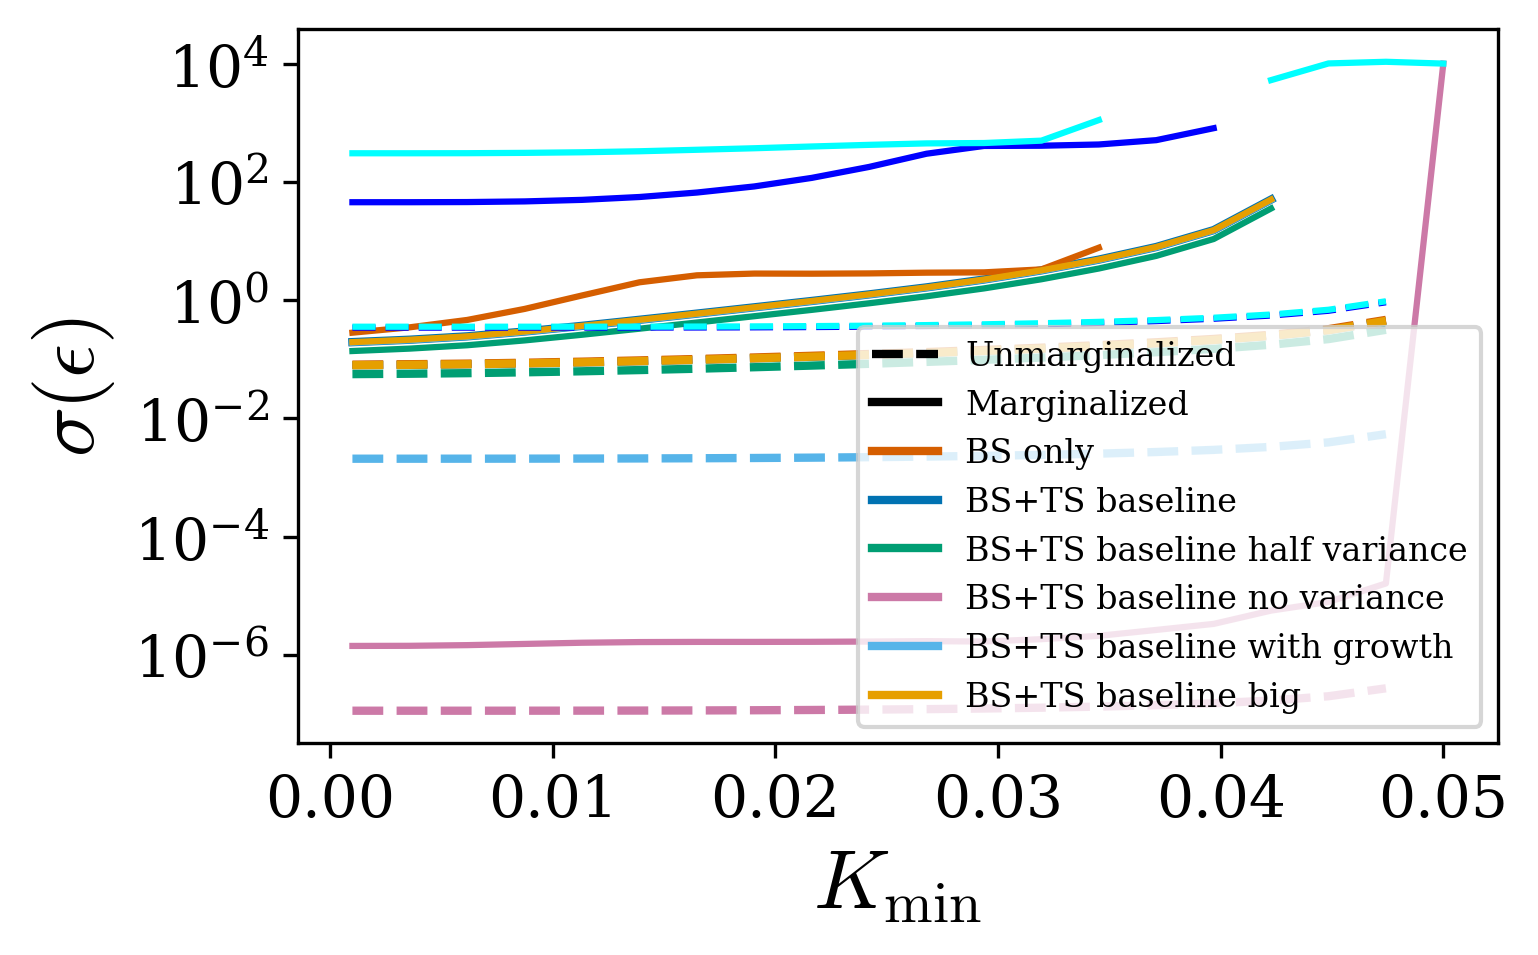

In [116]:
from matplotlib.lines import Line2D

fig = plt.figure(figsize=(FIG_WIDTH, FIG_HEIGHT), dpi=DPI, facecolor='white')
# Use GridSpec for more control over plot layout
gs = GridSpec(1, 1, figure=fig, left=0.15, right=0.95, bottom=0.15, top=0.92)
ax = fig.add_subplot(gs[0, 0])


index = 0

p1 = ax.plot(modes, err_with_variance_sub_us[:, index], ls = "--", color = COLORBLIND_PALETTE[0], lw = 2)
ax.plot(modes, err_with_variance_sub_ms[:, index], color = p1[0].get_color(), lw=2)

#ax.plot(modes, err_sub_2_us[:, 0], ls = "--", color = "green")
#ax.plot(modes, err_sub_2_ms[:, 0], color = "green")

#ax.plot(modes, err_us[:, 0], color = "blue", ls = ":")
#ax.plot(modes, err_ms[:, 0], ls = "--", color = "blue")

p2 = ax.plot(modes, err_single_sub_us[:, index], ls = "--", color = COLORBLIND_PALETTE[1], lw = 2)
ax.plot(modes, err_single_sub_ms[:, index], color = p2[0].get_color())

#ax.plot(modes, err_sub_us[:, 3], ls = "--", color = "red")
#ax.plot(modes, err_sub_ms[:, 3], color = "red")


p3 = ax.plot(modes, err_with_variance_half_sub_us[:, index], ls = "--", color = COLORBLIND_PALETTE[2], lw = 2)
ax.plot(modes, err_with_variance_half_sub_ms[:, index], color = p3[0].get_color())

p4 = ax.plot(modes, err_sub_us[:, 0], ls = "--", color = COLORBLIND_PALETTE[3], lw = 2)
ax.plot(modes, err_sub_ms[:, 0], color = p4[0].get_color())

p5 = ax.plot(modes, err_with_variance_growth_sub_us[:, index], ls = "--", color = COLORBLIND_PALETTE[4], lw = 2)
ax.plot(modes, err_with_variance_growth_sub_ms[:, index], color = p5[0].get_color())

p6 = ax.plot(modes, err_sub_big_us[:, index], ls = "--", color = COLORBLIND_PALETTE[5], lw = 2)
ax.plot(modes, err_sub_big_ms[:, index], ls = "-", color = p6[0].get_color())


#p7 = ax.plot(modes, err_with_variance_us[:, index], ls = "--", color = COLORBLIND_PALETTE[6], lw = 2)
#ax.plot(modes, err_with_variance_ms[:, index], ls = "-", color = p7[0].get_color())

#err_with_variance_no_shift_sub_ms, err_with_variance_no_shift_sub_us
ax.plot(modes, err_with_variance_no_shift_sub_us[:, index], ls = "--", color = "blue")
ax.plot(modes, err_with_variance_no_shift_sub_ms[:, index], ls = "-", color = "blue")

ax.plot(modes, err_single_no_shift_sub_us[:, index], ls = "--", color = "cyan")
ax.plot(modes, err_single_no_shift_sub_ms[:, index], ls = "-", color = "cyan")

ax.set_yscale("log")

ax.set_xlabel(r"$K_{\mathrm{min}}$", fontsize = 20)
ax.set_ylabel(r"$\sigma(\epsilon)$", fontsize = 20)


ax.tick_params(axis='both', which='major', width=0.8, 
               labelsize=14)


legend_elements = [Line2D([0], [0], color='black', lw=2, ls='--', label='Unmarginalized'),
                   Line2D([0], [0], color='black', lw=2, label='Marginalized'),
                   Line2D([0], [0], color=p2[0].get_color(), lw=2, label='BS only'),
                   Line2D([0], [0], color=p1[0].get_color(), lw=2, label='BS+TS baseline'),
                   Line2D([0], [0], color=p3[0].get_color(), lw=2, label='BS+TS baseline half variance'),
                   Line2D([0], [0], color=p4[0].get_color(), lw=2, label='BS+TS baseline no variance'),
                   Line2D([0], [0], color=p5[0].get_color(), lw=2, label='BS+TS baseline with growth'),
                   Line2D([0], [0], color=p6[0].get_color(), lw=2, label='BS+TS baseline big'),
                  ]
ax.legend(handles=legend_elements, fontsize=8)

In [61]:
# Clean, organized plotting code for Fisher matrix constraints
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

def plot_constraint_comparison(modes, error_data, baseline_key='bs_only', 
                             figsize=(10, 6), save_path=None):
    """
    Clean plotting function for comparing Fisher matrix constraints.
    
    Parameters:
    -----------
    modes : array
        K_min values
    error_data : dict
        Dictionary with keys as scenario names and values as tuples (unmarginalized, marginalized)
    baseline_key : str
        Key for the baseline scenario (for relative comparison)
    """
    
    # Define scenarios and their properties
    scenarios = {
        'bs_only': {
            'label': 'BS only (baseline)', 
            'color': 0, 
            'style': '-'
        },
        'bs_ts_baseline': {
            'label': 'BS+TS baseline', 
            'color': 1, 
            'style': '-'
        },
        'bs_ts_half_var': {
            'label': 'BS+TS half variance', 
            'color': 2, 
            'style': '-'
        },
        'bs_ts_no_var': {
            'label': 'BS+TS no variance', 
            'color': 3, 
            'style': '-'
        },
        'bs_ts_with_growth': {
            'label': 'BS+TS with growth', 
            'color': 4, 
            'style': '-'
        },
        'bs_ts_big': {
            'label': 'BS+TS big marginalization', 
            'color': 5, 
            'style': '-'
        }
    }
    
    # Create figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize, dpi=100)
    
    # Plot 1: Absolute constraints
    ax1.set_title('Absolute Constraints on ε', fontsize=14, pad=20)
    
    for scenario, props in scenarios.items():
        if scenario not in error_data:
            continue
            
        err_unmar, err_mar = error_data[scenario]
        color = COLORBLIND_PALETTE[props['color']]
        
        # Unmarginalized (dashed)
        ax1.plot(modes, err_unmar[:, 0], ls='--', color=color, 
                lw=2, alpha=0.7, label=f"{props['label']} (unmar.)")
        
        # Marginalized (solid)
        ax1.plot(modes, err_mar[:, 0], ls=props['style'], color=color, 
                lw=2.5, label=f"{props['label']} (mar.)")
    
    ax1.set_yscale('log')
    ax1.set_xlabel(r'$K_{\mathrm{min}}$ [h/Mpc]', fontsize=12)
    ax1.set_ylabel(r'$\sigma(\epsilon)$', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=8, loc='best')
    
    # Plot 2: Relative to baseline (marginalized only)
    ax2.set_title(f'Relative to {scenarios[baseline_key]["label"]}', fontsize=14, pad=20)
    
    if baseline_key in error_data:
        baseline_err = error_data[baseline_key][1][:, 0]  # marginalized baseline
        
        for scenario, props in scenarios.items():
            if scenario not in error_data or scenario == baseline_key:
                continue
                
            err_mar = error_data[scenario][1][:, 0]
            relative_err = err_mar / baseline_err
            
            color = COLORBLIND_PALETTE[props['color']]
            ax2.plot(modes, relative_err, ls=props['style'], color=color, 
                    lw=2.5, label=props['label'])
        
        # Add horizontal line at y=1 for reference
        ax2.axhline(y=1, color='black', ls=':', alpha=0.5, 
                   label=f'{scenarios[baseline_key]["label"]}')
    
    ax2.set_xlabel(r'$K_{\mathrm{min}}$ [h/Mpc]', fontsize=12)
    ax2.set_ylabel(r'$\sigma(\epsilon)$ / $\sigma(\epsilon)_{\mathrm{baseline}}$', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=8, loc='best')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig, (ax1, ax2)

# Usage example - organize your data like this:
def organize_error_data():
    """
    Organize your error arrays into a clean dictionary.
    Replace with your actual variable names.
    """
    error_data = {
        'bs_only': (err_single_sub_us, err_single_sub_ms),
        'bs_ts_baseline': (err_with_variance_sub_us, err_with_variance_sub_ms),
        'bs_ts_half_var': (err_with_variance_half_sub_us, err_with_variance_half_sub_ms),
        'bs_ts_no_var': (err_sub_us, err_sub_ms),
        'bs_ts_with_growth': (err_with_variance_growth_sub_us, err_with_variance_growth_sub_ms),
        'bs_ts_big': (err_sub_big_us, err_sub_big_ms),
        # Add more scenarios as needed
    }
    return error_data

# Clean implementation for your specific case:
def plot_epsilon_constraints():
    """Your specific plotting function"""
    
    # Organize your data
    error_data = organize_error_data()
    
    # Create the plot
    fig, axes = plot_constraint_comparison(
        modes, 
        error_data, 
        baseline_key='bs_only',
        figsize=(12, 5)
    )
    
    return fig, axes

# Alternative: Simple relative plot only
def plot_relative_constraints_only(modes, error_data, baseline_key='bs_only'):
    """
    Simplified version showing only relative constraints.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    baseline_err = error_data[baseline_key][1][:, 0]  # marginalized baseline
    
    scenarios = {
        'bs_ts_baseline': {'label': 'BS+TS baseline', 'color': 1},
        'bs_ts_half_var': {'label': 'BS+TS half variance', 'color': 2},
        'bs_ts_no_var': {'label': 'BS+TS no variance', 'color': 3},
        'bs_ts_with_growth': {'label': 'BS+TS with growth', 'color': 4},
        'bs_ts_big': {'label': 'BS+TS big marginalization', 'color': 5}
    }
    
    for scenario, props in scenarios.items():
        if scenario in error_data:
            err_mar = error_data[scenario][1][:, 0]
            relative_err = err_mar / baseline_err
            
            ax.plot(modes, relative_err, 
                   color=COLORBLIND_PALETTE[props['color']], 
                   lw=2.5, label=props['label'])
    
    ax.axhline(y=1, color='black', ls=':', alpha=0.7, label='BS only (baseline)')
    ax.set_xlabel(r'$K_{\mathrm{min}}$ [h/Mpc]', fontsize=14)
    ax.set_ylabel(r'$\sigma(\epsilon)$ / $\sigma(\epsilon)_{\mathrm{BS only}}$', fontsize=14)
    ax.set_title('Impact of Different Bias Marginalization Strategies', fontsize=16, pad=20)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=10)
    
    plt.tight_layout()
    return fig, ax

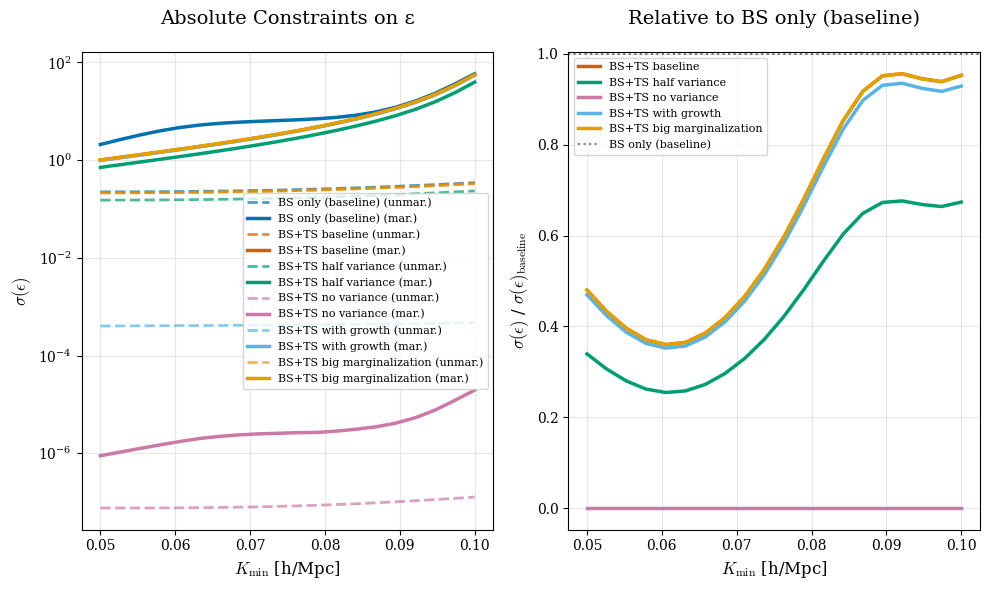

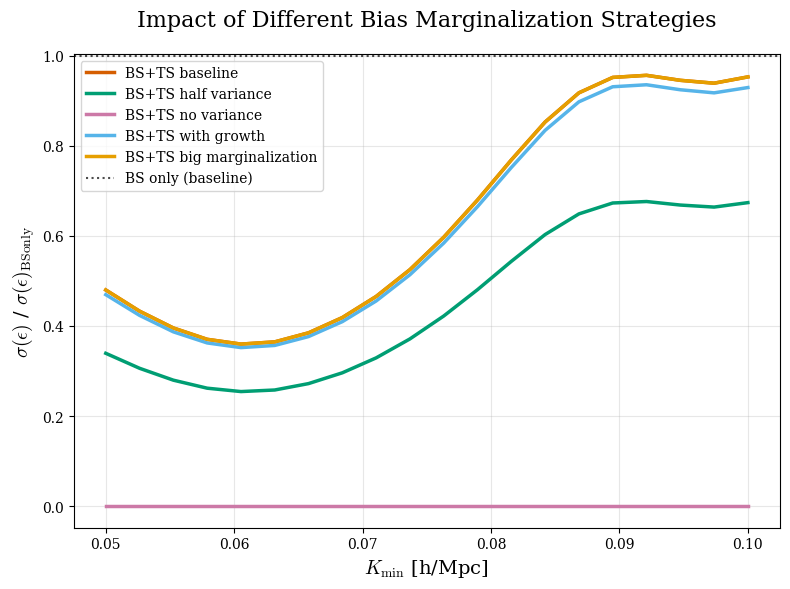

In [62]:
# Step 1: Organize your data into a dictionary
error_data = {
    'bs_only': (err_single_sub_us, err_single_sub_ms),
    'bs_ts_baseline': (err_with_variance_sub_us, err_with_variance_sub_ms),
    'bs_ts_half_var': (err_with_variance_half_sub_us, err_with_variance_half_sub_ms),
    'bs_ts_no_var': (err_sub_us, err_sub_ms),
    'bs_ts_with_growth': (err_with_variance_growth_sub_us, err_with_variance_growth_sub_ms),
    'bs_ts_big': (err_sub_big_us, err_sub_big_ms),
}

# Step 2: Create clean plots
fig, axes = plot_constraint_comparison(modes, error_data, baseline_key='bs_only')

# Or for just the relative plot:
fig_rel, ax_rel = plot_relative_constraints_only(modes, error_data, baseline_key='bs_only')